In [4]:
from glass.ete.lri import HeuristicLri
import os

In [2]:
dem = '/code/data/dem/ctr_rcls_dem.tif'

ws = '/code/data/results_lri_pnse'

bareas = '/code/data/aa_pnse_rst/rst_ba_1995_2023.tif'
bareas_by_year = '/code/data/aa_aoi_year_train'

_vars = {
    'dem'    : '/code/data/dem/ctr_rcls_dem.tif',
    'slope'  : '/code/data/slope/ctr_rcls_slope.tif',
    'aspect' : '/code/data/aspect/ctr_rcls_aspect.tif'
}

lulcs = [
    "/code/data/lulc/rst/lulc_1995.tif",
    "/code/data/lulc/rst/lulc_2007.tif",
    "/code/data/lulc/rst/lulc_2010.tif",
    "/code/data/lulc/rst/lulc_2015.tif",
    "/code/data/lulc/rst/lulc_2018.tif",
]


burncos = [
    "/code/data/aa_pnse_rst/rst_ba_1995_2006.tif",
    "/code/data/aa_pnse_rst/rst_ba_2007_2009.tif",
    "/code/data/aa_pnse_rst/rst_ba_2010_2014.tif",
    "/code/data/aa_pnse_rst/rst_ba_2015_2017.tif",
    "/code/data/aa_pnse_rst/rst_ba_2018_2023.tif",
]

weights = [12, 3, 5, 3, 6] #pesos associaos à estratégia temporal LULC-BA

out_dir = "/code/data/results_lri_pnse"
os.makedirs(out_dir, exist_ok=True)

out_susc = f"{out_dir}/res_lri.tif"
out_prob = f"{out_dir}/wprobability.tif"
out_peri = f"{out_dir}/res_perigosity.tif"

In [5]:
lri = HeuristicLri(ws, dem, loc=None)

In [6]:
# Import topographic variables

lri.import_topo_vars(dem=_vars['dem'], slope=_vars['slope'], aspect=_vars['aspect'])

# Import events
lri.import_events(bareas)

In [7]:
# Import LULC variables
lri.import_lulc_vars(lulcs, weights, burncos)

In [8]:
# Generate LRI
lri_res = lri.calc_lri(out=out_susc)

/usr/lib/python3/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [9]:
lri.export_vars_lri(os.path.dirname(out_susc), 'lri')

In [10]:
# Generate Wildfire probability

#wprob = lri.wildfire_probability(bareas_by_year, out=out_prob)

""" erro antes dq alteração


CalledModuleError: Module run `r.mapcalc expression=/code/data/results_lri_pnse/wprobability.tif = (rst_aa_2000 + rst_aa_2014 + rst_aa_2015 + rst_aa_2001 + rst_aa_2017 + rst_aa_2003 + rst_aa_2002 + rst_aa_2016 + rst_aa_2012 + rst_aa_2006 + rst_aa_2007 + rst_aa_2013 + rst_aa_2005 + rst_aa_2011 + rst_aa_2010 + rst_aa_2004 + rst_aa_1998 + rst_aa_1999 + rst_aa_1975 + rst_aa_1989 + rst_aa_1976 + rst_aa_1977 + rst_aa_1988 + rst_aa_1991 + rst_aa_1985 + rst_aa_1984 + rst_aa_1990 + rst_aa_1986 + rst_aa_1992 + rst_aa_1979 + rst_aa_1978 + rst_aa_1993 + rst_aa_1987 + rst_aa_1983 + rst_aa_1997 + rst_aa_1996 + rst_aa_1982 + rst_aa_1994 + rst_aa_1980 + rst_aa_1981 + rst_aa_1995 + rst_aa_2009 + rst_aa_2021 + rst_aa_2020 + rst_aa_2008 + rst_aa_2022 + rst_aa_2023 + rst_aa_2018 + rst_aa_2019) / 49.0 region=current --o --q` ended with an error.
The subprocess ended with a non-zero return code: 1. See errors above the traceback or in the error output."""



# Generate Wildfire probability
from glob import glob
from glass.rst.stats.grs import count_regionshp
from glass.it.rst import grs_to_rst

train_shps = sorted(glob(f"{bareas_by_year}/aa_*.shp"))

lri.wildfireprob = count_regionshp(
    train_shps,
    'rst_wildfireprob',
    return_prob=True,
    nnprob=len(train_shps)
)

grs_to_rst(lri.wildfireprob, out_prob, dtype="Float64", nodata=-1)

'/code/data/results_lri_pnse/wprobability.tif'

In [11]:
#from glass.it.rst import grs_to_rst

#wprob = lri.wildfire_probability(bareas_by_year)
#grs_to_rst(wprob, out_prob, dtype="Float64", nodata=-1)

In [12]:
# Generate perigosity

#lri.get_perigosity(out=out_peri)    alteração também

# Generate perigosity
lri.get_perigosity(
    inlri=out_susc,
    wildprob=out_prob,
    out=out_peri
)

'/code/data/results_lri_pnse/res_perigosity.tif'

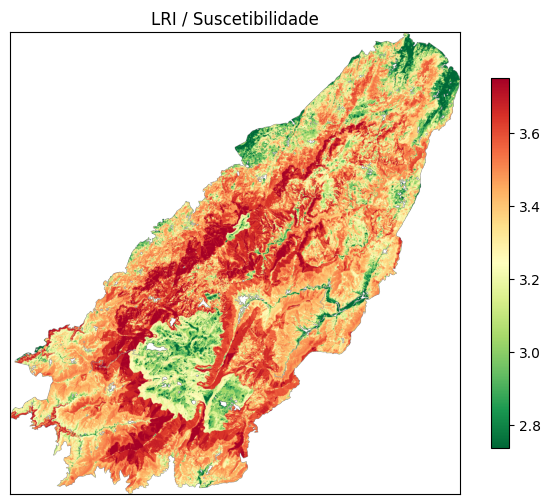

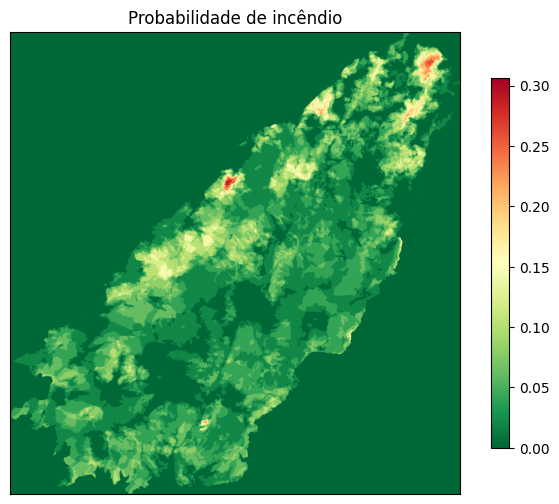

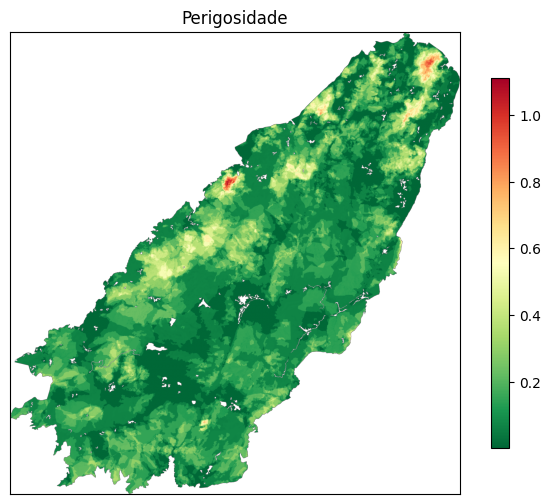

In [19]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def plot_raster(path, title, cmap='RdYlGn_r', stretch=False):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    fig, ax = plt.subplots(figsize=(8, 6))

    if stretch:
        vals = arr[~np.isnan(arr)]
        vmin = np.percentile(vals, 2)
        vmax = np.percentile(vals, 98)
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    else:
        im = ax.imshow(arr, cmap=cmap)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.show()


plot_raster(out_susc, 'LRI / Suscetibilidade', cmap='RdYlGn_r', stretch=True)
plot_raster(out_prob, 'Probabilidade de incêndio')
plot_raster(out_peri, 'Perigosidade')

In [20]:
#verificar o lri

import numpy as np
import rasterio

with rasterio.open(out_susc) as src:
    arr = src.read(1).astype(float)
    nodata = src.nodata

if nodata is not None:
    arr[arr == nodata] = np.nan

vals = arr[~np.isnan(arr)]

print("mínimo:", np.min(vals))
print("máximo:", np.max(vals))
print("média:", np.mean(vals))
print("desvio padrão:", np.std(vals))
print("percentis:", np.percentile(vals, [1, 5, 25, 50, 75, 95, 99]))


mínimo: 2.3012537688870403
máximo: 3.828048453552588
média: 3.3858722602320506
desvio padrão: 0.2498204727148713
percentis: [2.6674999  2.91594996 3.23536198 3.42998282 3.57244351 3.73249362
 3.75514401]


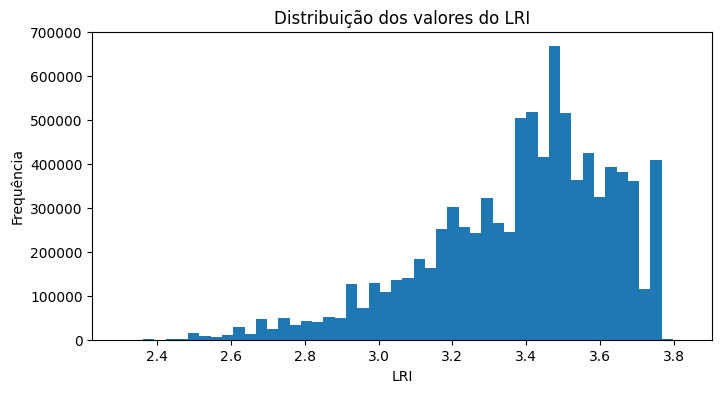

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(vals, bins=50)
plt.title("Distribuição dos valores do LRI")
plt.xlabel("LRI")
plt.ylabel("Frequência")
plt.show()

In [22]:
import os
import glob

files = sorted(glob.glob(f"{out_dir}/*lri*"))
for f in files:
    print(os.path.basename(f))

lri_aspect.tif
lri_dem.tif
lri_lulc.tif
lri_slope.tif
res_lri.tif


In [23]:
def raster_stats(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    vals = arr[~np.isnan(arr)]

    print(os.path.basename(path))
    print("  mínimo:", np.min(vals))
    print("  máximo:", np.max(vals))
    print("  média:", np.mean(vals))
    print("  desvio padrão:", np.std(vals))
    print("  percentis:", np.percentile(vals, [1, 25, 50, 75, 99]))
    print()

for f in files:
    raster_stats(f)

lri_aspect.tif
  mínimo: 0.805907403853143
  máximo: 1.0528598500394317
  média: 1.0006276168819865
  desvio padrão: 0.056575576787670306
  percentis: [0.8059074  0.97470341 1.02931679 1.04215762 1.05285985]

lri_dem.tif
  mínimo: 0.6157291166089693
  máximo: 1.2030030408689514
  média: 0.999999999999999
  desvio padrão: 0.14274063488488703
  percentis: [0.69224988 0.96778874 0.98864708 1.14360192 1.14360192]

lri_lulc.tif
  mínimo: 0.02070479633865136
  máximo: 0.5295843592361742
  média: 0.38188953050625374
  desvio padrão: 0.10132935001434387
  percentis: [0.1075166  0.35788579 0.37788976 0.47725902 0.47725902]

lri_slope.tif
  mínimo: 0.7719861312542972
  máximo: 1.082315886881305
  média: 1.000627616881986
  desvio padrão: 0.10810131333399325
  percentis: [0.77198613 0.87917435 1.08142321 1.08142321 1.08231589]

res_lri.tif
  mínimo: 2.3012537688870403
  máximo: 3.828048453552588
  média: 3.3858722602320506
  desvio padrão: 0.2498204727148713
  percentis: [2.6674999  3.23536198 3.

In [24]:
print(os.path.exists(out_susc), out_susc)
print(os.path.exists(out_prob), out_prob)
print(os.path.exists(out_peri), out_peri)

True /code/data/results_lri_pnse/res_lri.tif
True /code/data/results_lri_pnse/wprobability.tif
True /code/data/results_lri_pnse/res_perigosity.tif
